# Energy vs. Strain Calculations
**by <span style="color:darkgreen">Pasquale Pavone</span> & <span style="color:darkgreen">Konstantin Lion </span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial you will learn how to set up and execute a series of calculations for strained structures. Additionally, it will be explained how to obtain the derivatives of the energy-vs-strain curves at zero strain and how these quantities are related to elastic constants.

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Theoretical background](#1)

[2. Set up the calculations](#2)
    
* [Preparation of the input file](#2-1)
* [Generation of input files for distorted structures](#2-2)
    
[3.  Execute the calculations](#3)
 
[4.  Post-processing: Extract energy derivatives](#4)
    
[5.  Post-processing: Visualization tools](#5)
    
[6.  Post-processing: How to derive elastic constants](#6) 
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

Here is a list of the scripts which are relevant for this tutorial with a short description.

* <code><b>setup.elastic_strain.py</b></code>: Python script for generating strained structures.
* <code><b>execute.elastic_strain.py</b></code>: Python script for running a series of <code><b>exciting</b></code> calculations.
* <code><b>checkfit.energy_vs_strain.py</b></code>: Python script for extracting derivatives at zero strain of energy-vs-strain curves.
* <code><b>plot.energy.py</b></code>: Python visualization tool for energy-vs-strain curves.
* <code><b>plot.status.py</b></code>: Python visualization tool for <b>RMS</b> deviations of the <b>SCF</b> potential as a function of the iteration number during the SCF loop.
* <code><b>plot.maxforce.py</b></code>: Python visualization tool for the maximum amplitude of the force on the atoms during relaxation.
* <code><b>plot.checkderiv.py</b></code>: Python visualization tool for the calculation of derivatives at zero strain using the fit of energy-vs-strain curves.
* <code><b>plot.optimized_geometry.py</b></code>: Python visualization tool for relaxed coordinates of atoms in the unit cell.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background</span>

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Theory of linear elasticity</span></strong> 
    
</summary>    

The energy of a crystal depends on the <span style="color:mediumblue;font-weight:bold;">state of distorsion</span> in which the crystal is found. Usually, the "measure" of the state of distortion is given either in terms of the <span style="color:red;font-weight:bold;">physical-strain matrix</span>:

<a id='e1'></a>
\begin{equation}
\tag{1}
\boldsymbol{\epsilon} = \begin{pmatrix}
\epsilon_{xx} & \epsilon_{yx} & \epsilon_{zx} \\
\epsilon_{xy} & \epsilon_{yy} & \epsilon_{zy} \\
\epsilon_{xz} & \epsilon_{yz} & \epsilon_{zz}
\end{pmatrix},
\end{equation}
    
or in terms of the <span style="color:green;font-weight:bold;">Lagrangian-strain matrix</span>:

<a id='e2'></a>
\begin{equation}
\tag{2}
\boldsymbol{\eta} = \begin{pmatrix}
\eta_{xx} & \eta_{yx} & \eta_{zx} \\
\eta_{xy} & \eta_{yy} & \eta_{zy} \\
\eta_{xz} & \eta_{yz} & \eta_{zz}
\end{pmatrix},
\end{equation}
    
where $\boldsymbol{\epsilon}$ and $\boldsymbol{\eta}$ are symmetric matrices and are related to each other by the relationship

<a id='e3'></a>
\begin{equation}
\tag{3}
\boldsymbol{\eta} = \boldsymbol{\epsilon} + \frac{1}{2}\boldsymbol{\epsilon}^2.
\end{equation}
    
The actual deformation of the crystal is given by

<a id='e4'></a>
\begin{equation}
\tag{4}
\boldsymbol{r'} = (\boldsymbol{1} + \boldsymbol{\epsilon}) \cdot \boldsymbol{r}.
\end{equation}
    
Using the previous definitions, the total energy of a crystal can be written as a Taylor expansion in terms of powers of the Lagrangian strain

<a id='e5'></a>
\begin{equation}
\tag{5}
E[\boldsymbol{\eta}] = E_0 + \sum_{ij} \sigma_{ij}^{(0)} \eta_{ij} + \frac{1}{2} \sum_{ij,kl} C_{ij,kl}^{(2)} \eta_{ij} \eta_{kl} + \frac{1}{6} \sum_{ij,kl,mn} C_{ij,kl,mn}^{(3)} \eta_{ij} \eta_{kl} \eta_{mn} + \cdots
\end{equation}
    
where $\sigma_{ij}^{0} = 0$ is the reference (unstrained) configuration is the equilibrium one. The other coefficients in this Taylor expansion are defined as <span style="color:mediumblue;font-weight:bold;">elastic constants</span> of different order, e.g., the elastic constants of the 2nd order (called also linear elastic constants) are

<a id='e6'></a>
\begin{equation}
\tag{6}
C_{ij,kl}^{(2)} = \left. \frac{\partial^2 E[\eta]}{\partial \eta_{ij} \partial \eta_{kl}} \right|_{\eta = 0}.
\end{equation}
    
The results above are often expressed in terms of the <span style="color:mediumblue;font-weight:bold;">Voigt notation</span>, which is a way to represent a symmetric tensor by reducing its order. Thus, following this notation the strain matrices above can be represented as vectors in a six-dimensional space:

<a id='e7'></a>
\begin{equation}
\tag{7}
\boldsymbol{\eta}_{\text{Voigt}} \equiv \tilde{\boldsymbol{\eta}} = (\eta_1, \eta_2, \eta_3, \eta_4, \eta_5, \eta_6) \equiv (\eta_{xx}, \eta_{yy}, \eta_{zz}, 2\eta_{yz}, 2\eta_{xz}, 2\eta_{xy}).
\end{equation}
    
The Taylor expansion of the elastic energy can be rewritten using Voigt notation as

<a id='e8'></a>
\begin{equation}
\tag{8}
E[\tilde{\boldsymbol{\eta}}] = E_0 + \boldsymbol{\sigma}^{(0)} \cdot \tilde{\boldsymbol{\eta}} + \frac{1}{2} \tilde{\boldsymbol{\eta}} \cdot \boldsymbol{C}^{(2)} \cdot \tilde{\boldsymbol{\eta}} + \cdots
\end{equation}
    
where $\boldsymbol{C}^{(2)}$ is the $6 \times 6$ matrix

<a id='e9'></a>
\begin{equation}
\tag{9}
\boldsymbol{C}^{(2)} \equiv \boldsymbol{C} = \begin{pmatrix}
C_{11} & C_{21} & C_{31} & C_{41} & C_{51} & C_{61} \\
C_{12} & C_{22} & C_{32} & C_{42} & C_{52} & C_{62} \\
C_{13} & C_{23} & C_{33} & C_{43} & C_{53} & C_{63} \\
C_{14} & C_{24} & C_{34} & C_{44} & C_{54} & C_{64} \\
C_{15} & C_{25} & C_{35} & C_{45} & C_{55} & C_{65} \\
C_{16} & C_{26} & C_{36} & C_{46} & C_{56} & C_{66}
\end{pmatrix}.
\end{equation}
    
For a given crystal structure, the number of independent elastic-constants components can be reduced using the crystal symmetry. For instance, for cubic systems the matrix of the elastic constants reduces to

<a id='e10'></a>
\begin{equation}
\tag{10}
\boldsymbol{C}_{\text{cubic}} = \begin{pmatrix}
C_{11} & C_{12} & C_{12} & 0 & 0 & 0 \\
C_{12} & C_{11} & C_{12} & 0 & 0 & 0 \\
C_{12} & C_{12} & C_{11} & 0 & 0 & 0 \\
0 & 0 & 0 & C_{44} & 0 & 0 \\
0 & 0 & 0 & 0 & C_{44} & 0 \\
0 & 0 & 0 & 0 & 0 & C_{44}
\end{pmatrix}.
\end{equation}
    
</details>    

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Set up the calculations</span>

<a id='2-1'></a>
<b>i) Preparation of the input file</b>

The first step is to create a directory for each system that you want to investigate. Here, we consider the calculation of the energy-vs-strain curves for carbon in the diamond structure. However, the procedure we show you is <b>valid for any system</b>. Thus, we will create a directory <b>run_diamond_elastic_strain</b>.

In [ ]:
%%bash -l
mkdir -p run_diamond_elastic_strain

Inside this directory, we create (or copy from a previous calculation) the file <b>input.xml</b> corresponding to a calculation for the equilibrium structure of diamond. This file could look like the following.

<span class="DIAMOND_INPUT"></span>
```xml
<input>
 
   <title>Diamond: Equilibrium structure</title>
 
   <structure speciespath="$EXCITINGROOT/species">
      <crystal scale="6.714">
         <basevect> 0.5     0.5     0.0 </basevect>
         <basevect> 0.5     0.0     0.5 </basevect>
         <basevect> 0.0     0.5     0.5 </basevect>
      </crystal>
      <species speciesfile="C.xml" rmt="1.25">
         <atom coord="0.00 0.00 0.00" />
         <atom coord="0.25 0.25 0.25" />
      </species>
   </structure>
 
   <groundstate 
      ngridk="8 8 8"
      swidth="0.0001"
      gmaxvr="14"
      xctype="GGA_PBE_SOL">
   </groundstate>
 
   <relax/>
 
</input>
```

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("energy_vs_strain_calculations", "DIAMOND_INPUT")

# Write out the input as an XML file:
with open('./run_diamond_elastic_strain/input.xml', "w") as fid:
    fid.write(input_str)

Please, remember that the input file for an <code><b>exciting</b></code> calculation must always be called <b>input.xml</b>.

<b>Be sure to set</b> the correct path for the <code><b>exciting</b></code> root directory (indicated in this example by <code><span style="color:mediumblue">$EXCITINGROOT</span></code>) to the one pointing to the place where the <code><b>exciting</b></code> directory is placed. In order to do this, use the command

In [ ]:
%%bash -l
cd run_diamond_elastic_strain
python3 -m excitingscripts.setup.excitingroot
cd ..

<b>Be sure</b> to have in your file the appropriate command for performing the structure optimization: Deforming your system may change the relative positions of the atoms in the unit cell.

<code><span style="color:green">&ltrelax/&gt</span></code>

<a id='2-2'></a>
<b>ii) Generation of input files for distorted structures</b>

All strains considered in this tutorial are Lagrangian strains.

In order to generate input files for a series of distorted structures, you have to run the script <code><b>setup.elastic_strain.py</b></code>. <b>Notice</b> that the script <code><b>setup.elastic_strain.py</b></code> always generates a working directory containing input files for different strains. Results of the current calculations will be also stored in the working directory. The directory name can be specified by adding the name in the command line.

<code>$ python3 -m excitingscripts.setup.elastic_strain -r DIRECTORYNAME --s-max MAX_STRAIN -n NUMBEROFSTRAINVALUES -d DEFORMATIONCODE</code>

If no name is given, the script use the default name <b>workdir</b>. <span style="color:red;font-weight:bold;">Very important</span>: The working directory is overwritten each time you execute the script <code><b>setup.elastic_strain.py</b></code>. Therefore, choose different names for different calculations.

The script <code><b>setup.elastic_strain.py</b></code> produces the following output on the screen (using <b>deformation-0</b> as working directory).

In [ ]:
%%bash -l
cd run_diamond_elastic_strain
python3 -m excitingscripts.setup.elastic_strain -r deformation-0 --s-max 0.10 -n 11 -d 0
cd ..


```

------------------------------------------------------------------------
 List of deformation codes for strains in Voigt notation
------------------------------------------------------------------------
  0 =>  ( eta,  eta,  eta,    0,    0,    0)  | volume strain 
  1 =>  ( eta,    0,    0,    0,    0,    0)  | linear strain along x 
  2 =>  (   0,  eta,    0,    0,    0,    0)  | linear strain along y 
  3 =>  (   0,    0,  eta,    0,    0,    0)  | linear strain along z 
  4 =>  (   0,    0,    0,  eta,    0,    0)  | yz shear strain
  5 =>  (   0,    0,    0,    0,  eta,    0)  | xz shear strain
  6 =>  (   0,    0,    0,    0,    0,  eta)  | xy shear strain
  7 =>  (   0,    0,    0,  eta,  eta,  eta)  | shear strain along (111)
  8 =>  ( eta,  eta,    0,    0,    0,    0)  | xy in-plane strain 
  9 =>  ( eta, -eta,    0,    0,    0,    0)  | x(-y) in-plane strain
 10 =>  ( eta,  eta,  eta,  eta,  eta,  eta)  | global strain
 11 =>  ( eta,    0,    0,  eta,    0,    0)  | mixed strain
 12 =>  ( eta,    0,    0,    0,  eta,    0)  | mixed strain
 13 =>  ( eta,    0,    0,    0,    0,  eta)  | mixed strain
 14 =>  ( eta,  eta,    0,  eta,    0,    0)  | mixed strain
------------------------------------------------------------------------

```

Entry values must be typed as arguments. The first entry (in our example <span style="color:red;font-weight:bold;">0.10</span>) represents the absolute value of the maximum strain for which we want to perform the calculation. The second entry (<span style="color:red;font-weight:bold;">11</span>) is the number of deformed structures equally spaced in strain, which are generated between the maximum negative strain and the maximum positive one. The third (last) entry (<span style="color:red;font-weight:bold;">0</span>) is a self-explained label indicating the type of deformation. The latter is always referred to 2-dimensional strain tensors in the Voigt notation (so that, *e.g*., a strain value of 0.10 corresponds, for the choice 1 of the deformation code, to a linear deformation of 10% along the x direction).

After running the script, a directory called <b>deformation-0</b> is created. Inside this directory, the input file <b>input-i.xml</b> are contained in the subdirectory <b>rundir-<i>i</i></b> where <b><i>i</i></b> is running from <b>01</b> to the total number of strain values.

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Execute the calculations</span>

To execute the series of calculations with input files created by <code><b>setup.elastic_strain.py</b></code> you have to run the script <code><b>execute.elastic_strain.py</b></code>. If a name for the working directory has been specified, then you <b>must</b> give it here, too.

In [ ]:
%%bash -l
cd run_diamond_elastic_strain
python3 -m excitingscripts.execute.elastic_strain -r deformation-0
cd ..

After the complete run, move to the working directory deformation-0.

Inside this directory, results of the calculation for the input file <b>input-i.xml</b> are contained in the subdirectory <b>rundir-<i>i</i></b> where <b><i>i</i></b> is running from <b>1</b> to the total number of strain values. The data for energy-vs-strain curves are contained in the file <b>energy-vs-strain</b>.

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. Post-processing: Extract energy derivatives</span>

At this point, inside the directory <b>deformation-0</b>, you can use the python script <b>checkfit.energy_vs_strain.py</b> for extracting derivatives at zero strain of energy-vs-strain curves.

In [ ]:
%%bash -l
cd run_diamond_elastic_strain/deformation-0
python3 -m excitingscripts.checkfit.energy_vs_strain --s-max 0.10 -o 2 
cd ../../

```
###########################################

Fit data-----------------------------------

Deformation code             ==> 0
Deformation label            ==> EEE000
Maximum value of the strain  ==> 0.10000000
Number of strain values used ==> 11

Fit results for the derivative of order   2

Polynomial of order  2 ==>   4467.22 [GPa]
Polynomial of order  3 ==>   4467.22 [GPa]
Polynomial of order  4 ==>   4053.46 [GPa]
Polynomial of order  5 ==>   4053.46 [GPa]
Polynomial of order  6 ==>   4060.23 [GPa]
Polynomial of order  7 ==>   4060.23 [GPa]

###########################################
```

The first entry (in our example <span style="color:red;font-weight:bold;">0.10</span>) represents the absolute value of the maximum strain for which we want to perform the calculation. The second entry (<span style="color:red;font-weight:bold;">2</span>) is the order of the derivative that we want to obtain.

The script generates the output files <b>checkfit_energy_results.json</b>, which can be used in the post-processing analysis. Results of this script can be analyzed using the visualization tool <code><b>plot.checkderiv.py</b></code>.

<a id='5'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">5. Post-processing: Visualization tools</span>

<span style="color:green">All the scripts mentioned here must be executed in the directory where the <b>energy-vs-strain</b>, and <b>checkfit_energy_results.json</b> files are located. The scripts produce as output a <b>png</b> file (<b>PLOT.png</b>).</span>

<b>i) <code>plot.checkderiv.py</code></b>

The script <code><b>plot.checkderiv.py</b></code>, which requires as input the <b>checkfit_energy_results.json</b> files generated by <code><b>checkfit.energy_vs_strain.py</b></code> generates the file <b>PLOT_checkderiv.png</b> which show the dependence of the calculated derivatives of the energy-vs-strain curve on:

* the range of points included in the fitting procedure ("<span style="color:green;font-weight:bold">maximum lagrangian strain</span>"),
* the maximum degree of the polynomial used in the fitting procedure ("<span style="color:green;font-weight:bold">n</span>").

The script is executed as follows.

<code>python3 -m excitingscripts.plot.checkderiv --y_min YMIN --y_max YMAX energy</code>

Differently from the plot generated automatically, by using <code><b>plot.checkderiv.py</b></code>, via the two <span style="color:red;font-weight:bold">optional</span> entries <span style="color:red;font-weight:bold">YMIN</span> and <span style="color:red;font-weight:bold">YMAX</span>, which can be specified <span style="color:red;font-weight:bold">on the calling line</span>, it is possible to specify the minimum and the maximum value on the vertical axis, respectively. If only one value is given it is interpreted as <span style="color:red;font-weight:bold">YMIN</span>. An example of the script output for the calculations performed in the directory <span style="color:mediumblue;font-weight:bold">deformation-0</span> is the following.


In [ ]:
%%bash -l
cd run_diamond_elastic_strain/deformation-0
python3 -m excitingscripts.plot.checkderiv --y_min 4030.5 --y_max 4490.2 energy 
cd ../../

<figure>
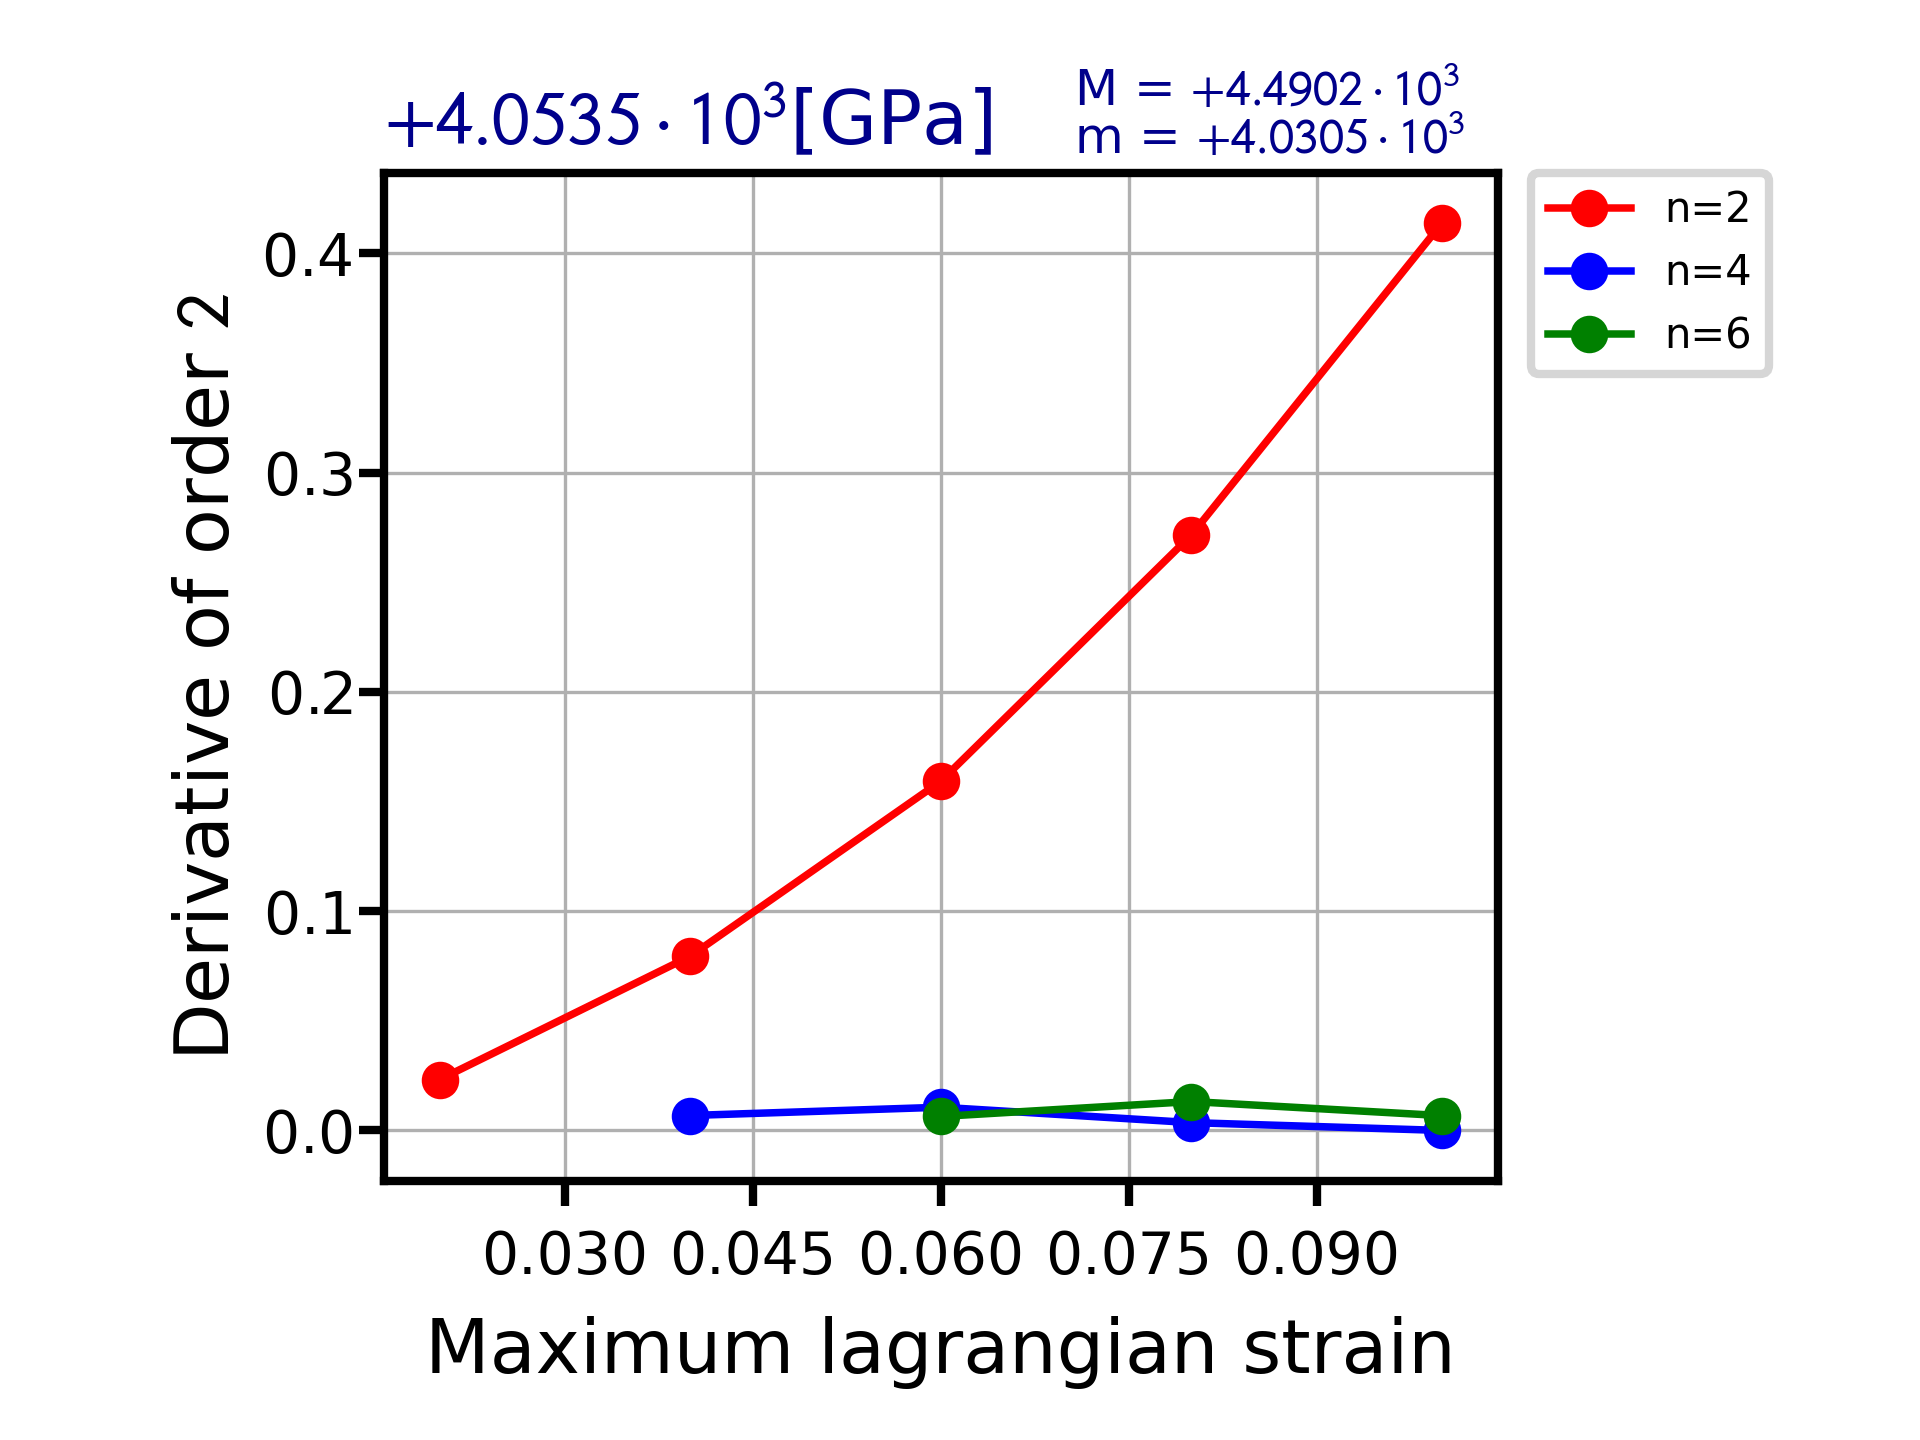
</figure>



The previous plots can be used to determine the best range of deformations and order of polynomial fit for each distortion. By analyzing the plot, we note that curves corresponding to the higher order of the polynomial used in the fit show a <span style="color:green;font-weight:bold">horizontal plateau at about 4060 GPa</span>. This can be assumed to be the <span style="color:red;font-weight:bold">converged value</span> for the second derivative, <span style="color:red;font-weight:bold">from the point of view of the fit</span> (further information on this topic can be found [<span style="color:firebrick;font-weight:bold">here</span>](http://exciting.wdfiles.com/local--files/beryllium-elastic/elastic-paper.pdf)). For this distortion type, this value equals 9 times the bulk modulus. Thus, the extracted value of the <span style="color:green;font-weight:bold">bulk modulus is about 451 GPa</span>.

<b>ii) <code>plot.energy.py</code></b>

This script allows for the visualization of the energy-vs-strain curve. It is executed as follows.

In [ ]:
%%bash -l
cd run_diamond_elastic_strain/deformation-0
python3 -m excitingscripts.plot.energy
cd ../../

In the following, we display the result for the calculations performed in the directory <span style="color:mediumblue;font-weight:bold">deformation-0</span> (carbon in the diamond structure, volume-strain deformations up to 10%).
 
<figure>
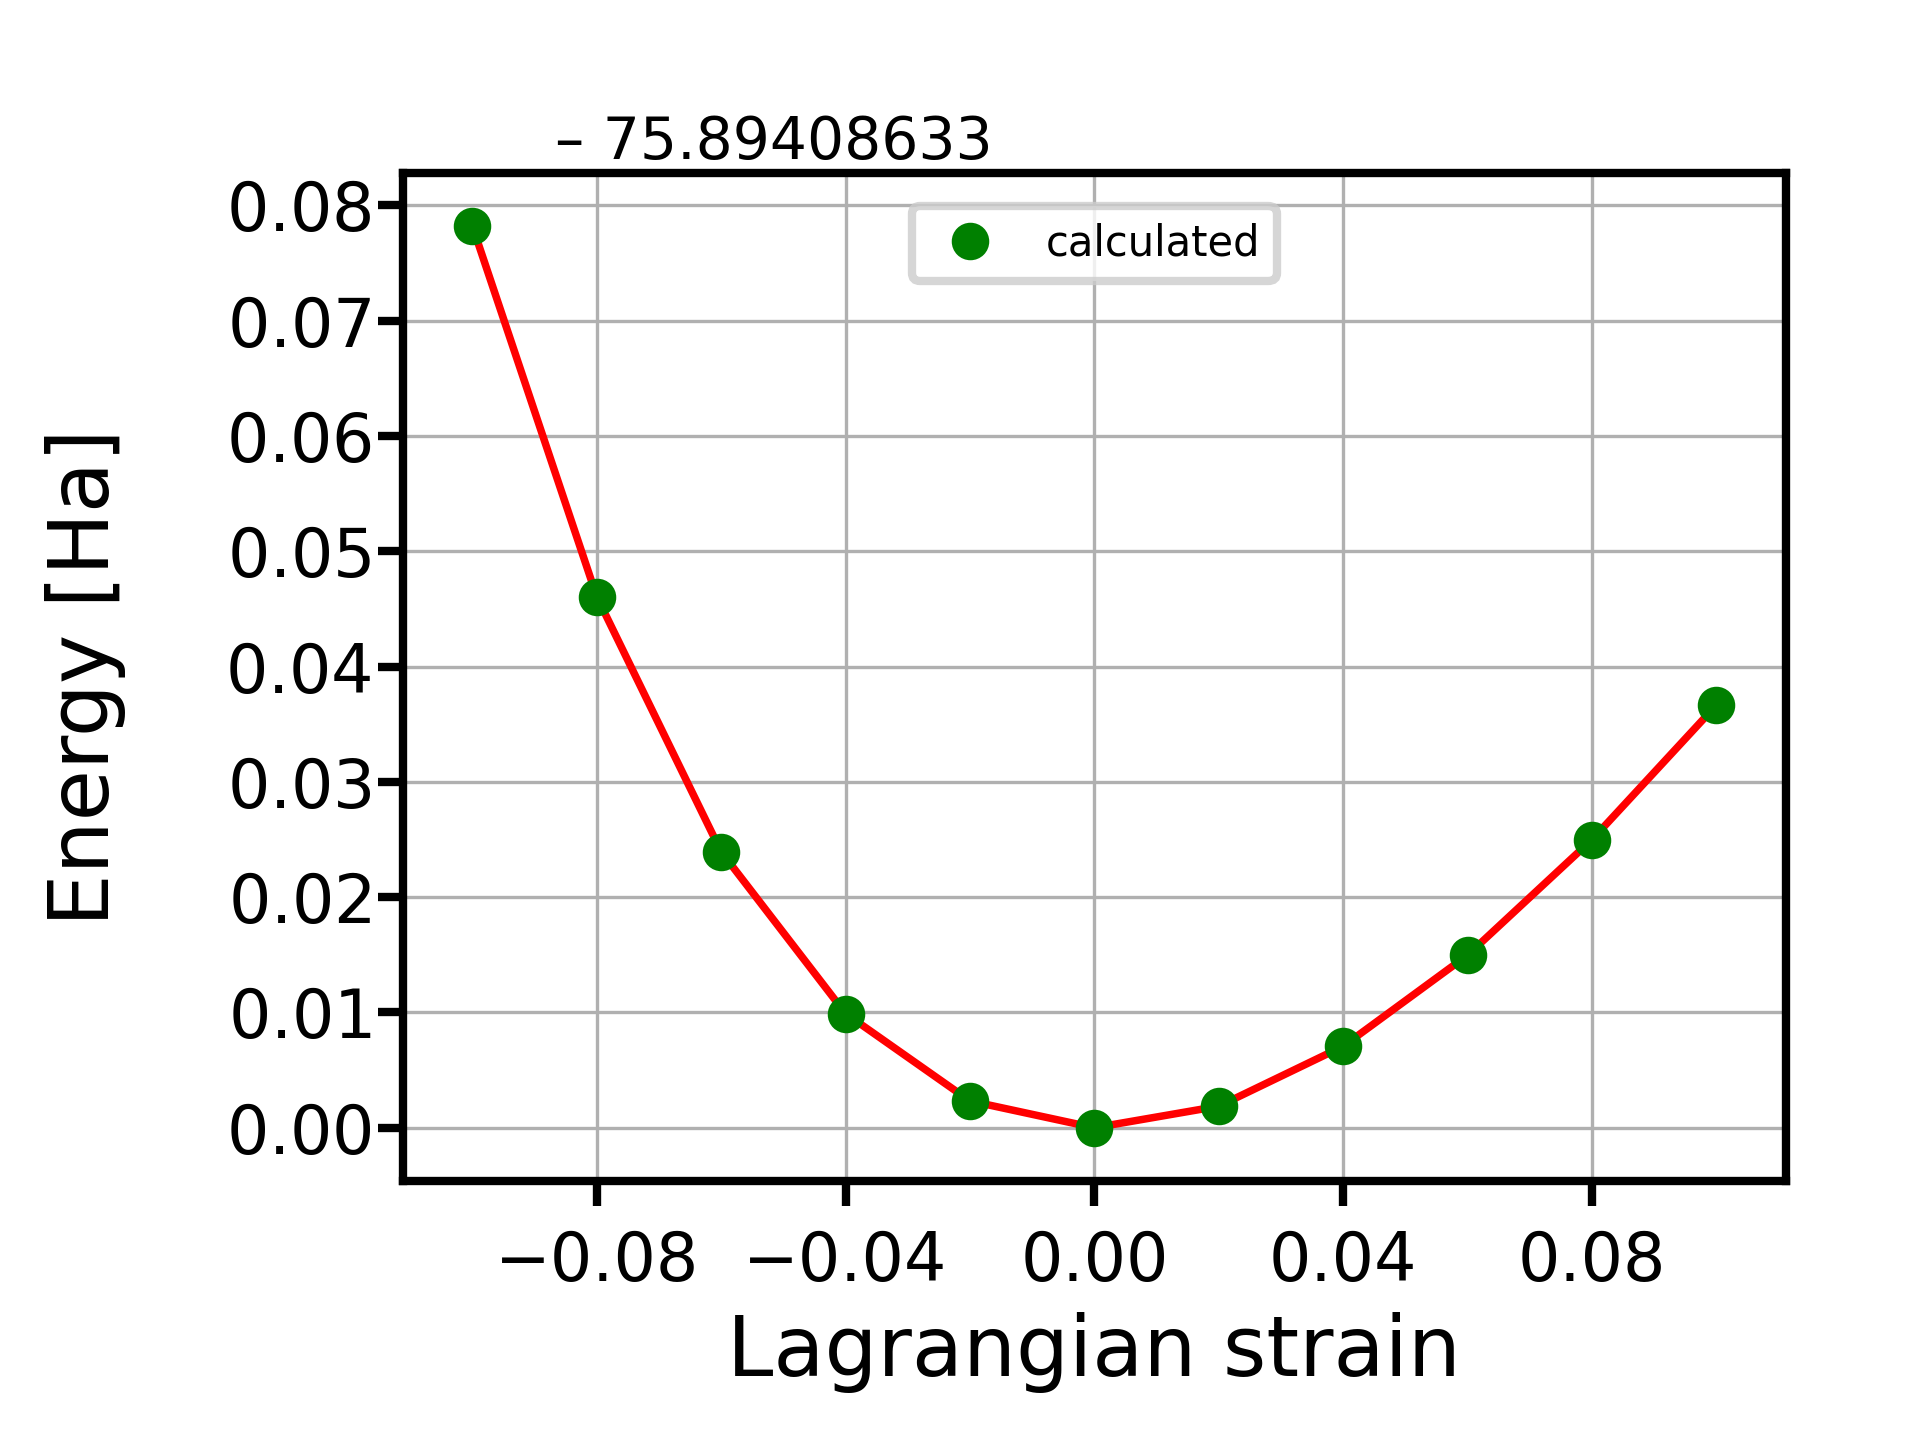
</figure>

<b>iii) <code>plot.status.py</code></b>

Python visualization tool for the <b>RMS</b> deviations of the effective <b>SCF</b> potential as a function of the iteration number during the <b>SCF</b> loop. It is executed as follows.

<code>python3 -m excitingscripts.plot.status LABEL</code>

Here, the entry on the command line, <b>LABEL</b>, <span style="color:red;font-weight:bold">must</span> be specified and represents the name of the directory where an <code><b>exciting</b></code> calculation has been or is still running. The <code><b>plot.status.py</b></code> script is particularly useful in the latter case because one can follow *"live"* the convergence of the calculation. An example of the output of the script for the calculations performed in the directory <span style="color:mediumblue;font-weight:bold">deformation-7/rundir-01</span> (to be able to visualize it run <code><b>setup.elastic_strain.py</b></code> for the deformation identified by the <span style="color:red;font-weight:bold">code 7</span>) is the following.



<figure>
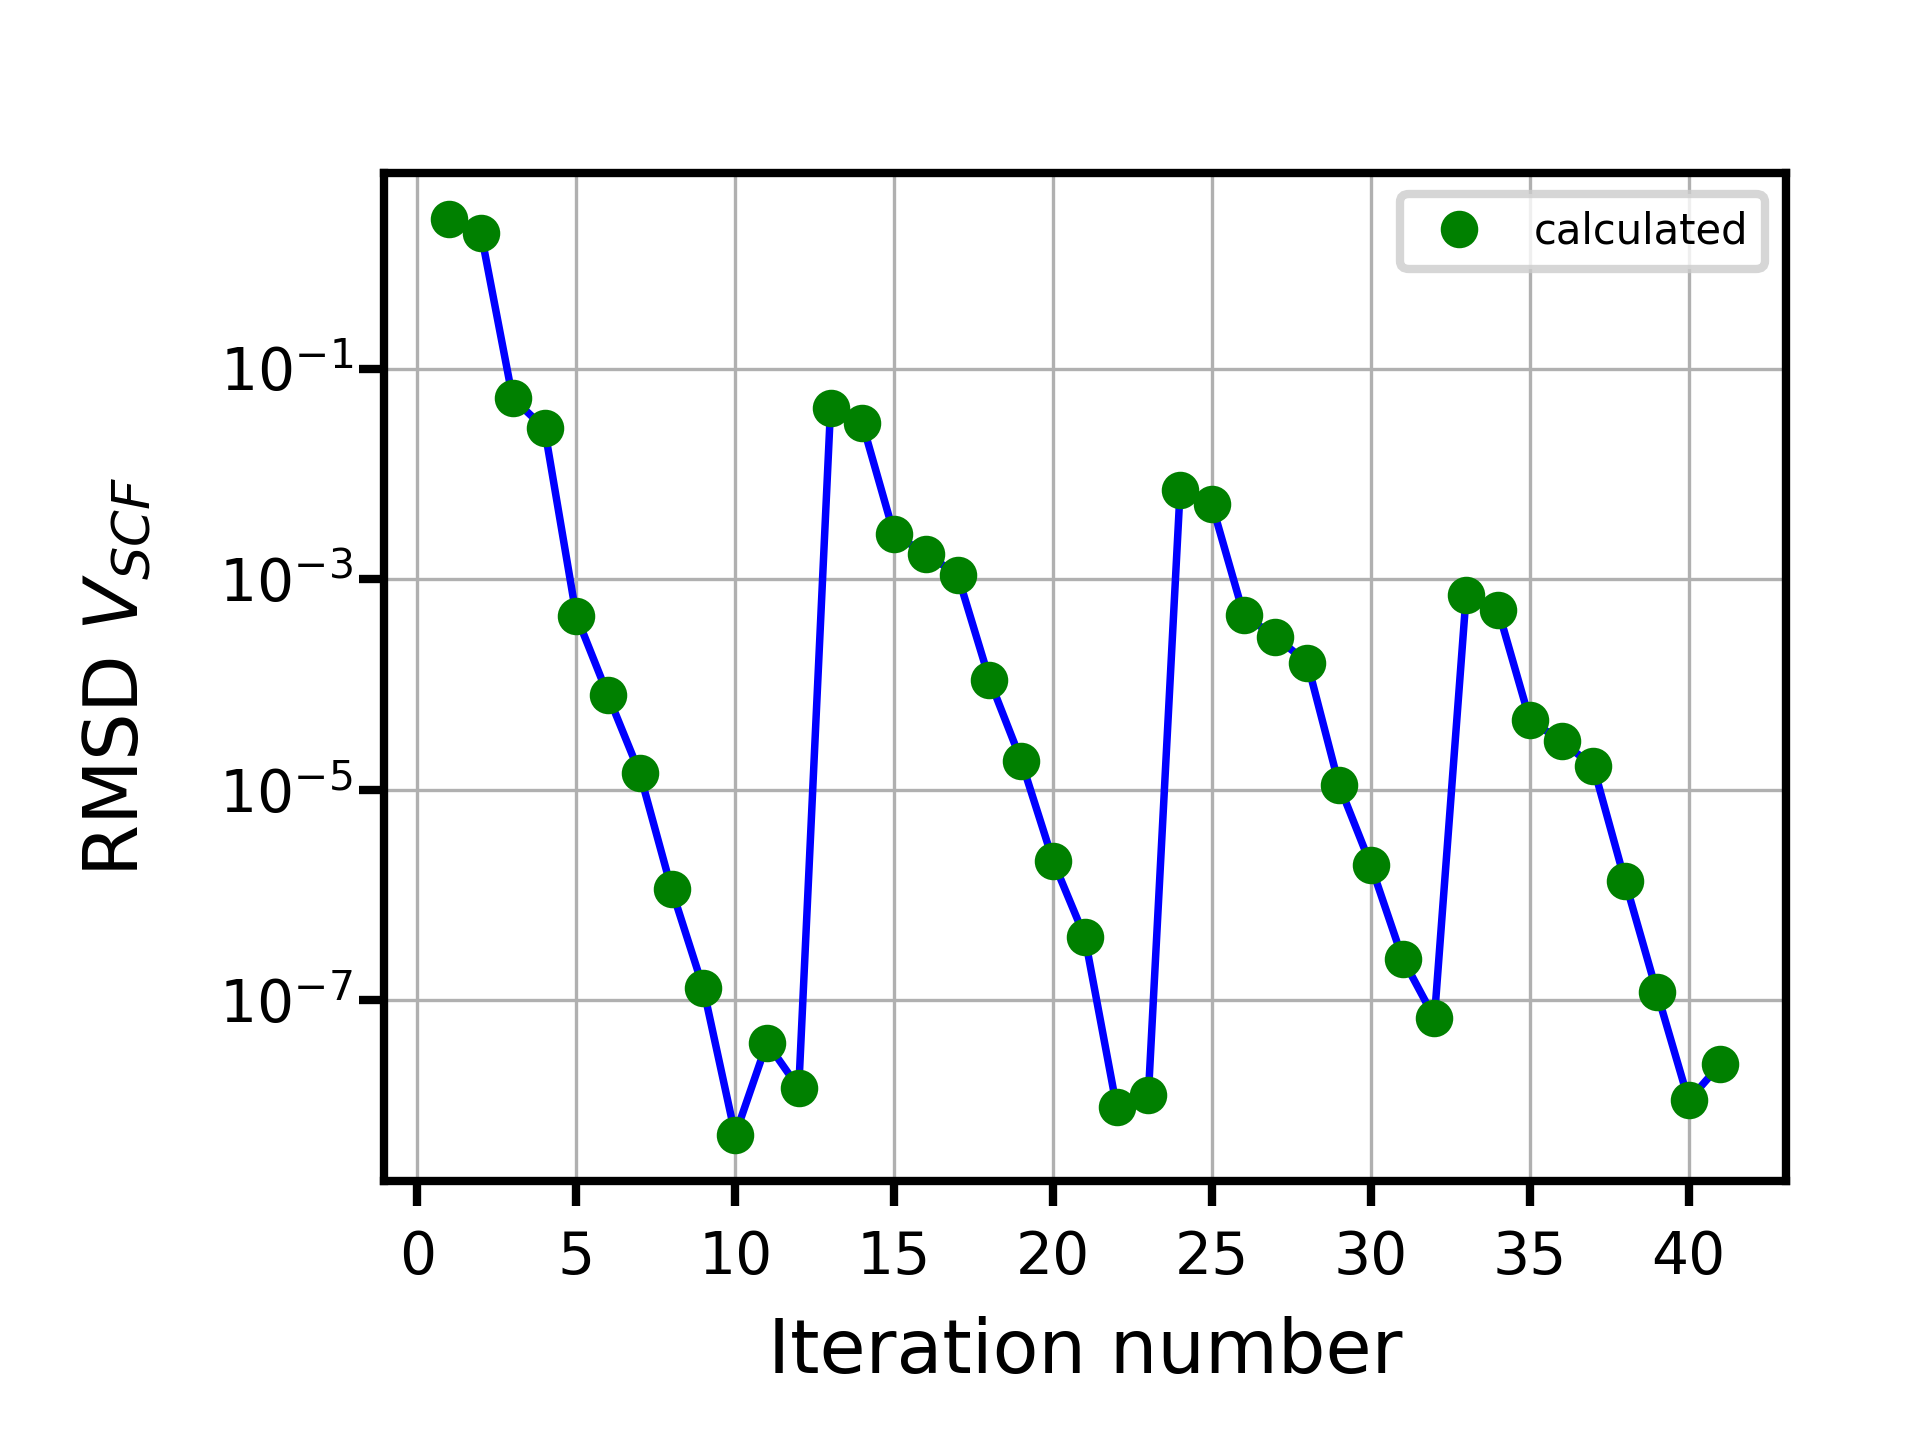
</figure>


Different line segments correspond to SCF calculations for different geometries during the relaxation.

<b>iv) <code>plot.maxforce.py</code></b>.

Python visualization tool for the maximum amplitude of the force on atoms during relaxation. <span style="color:green;font-weight:bold">It is useful for deformations which allow for internal relaxation of atomic positions, e.g., for the deformation with the code</span> <span style="color:red;font-weight:bold">7</span>. It is executed as follows.

<code>python3 -m excitingscripts.plot.maxforce LABEL</code>

The input entry definition is the same as for the script <code><b>plot.status.py</b></code>. If the symmetry of the deformation applied to the crystal is such that no extra force is applied to the atoms (e.g., as it happens for deformation <span style="color:red;font-weight:bold">1</span> and <span style="color:red;font-weight:bold">2</span>) the output of the script <code><b>plot.maxforce.py</b></code> will be
```
Either data file not (yet) ready for visualization 
or maximum force target reached already at the initial configuration.
```
Otherwise a plot will be produced as output. An example of the script output (for the deformation type 7 in the directory <span style="color:mediumblue;font-weight:bold">rundir-01</span>) is the following.

<figure>
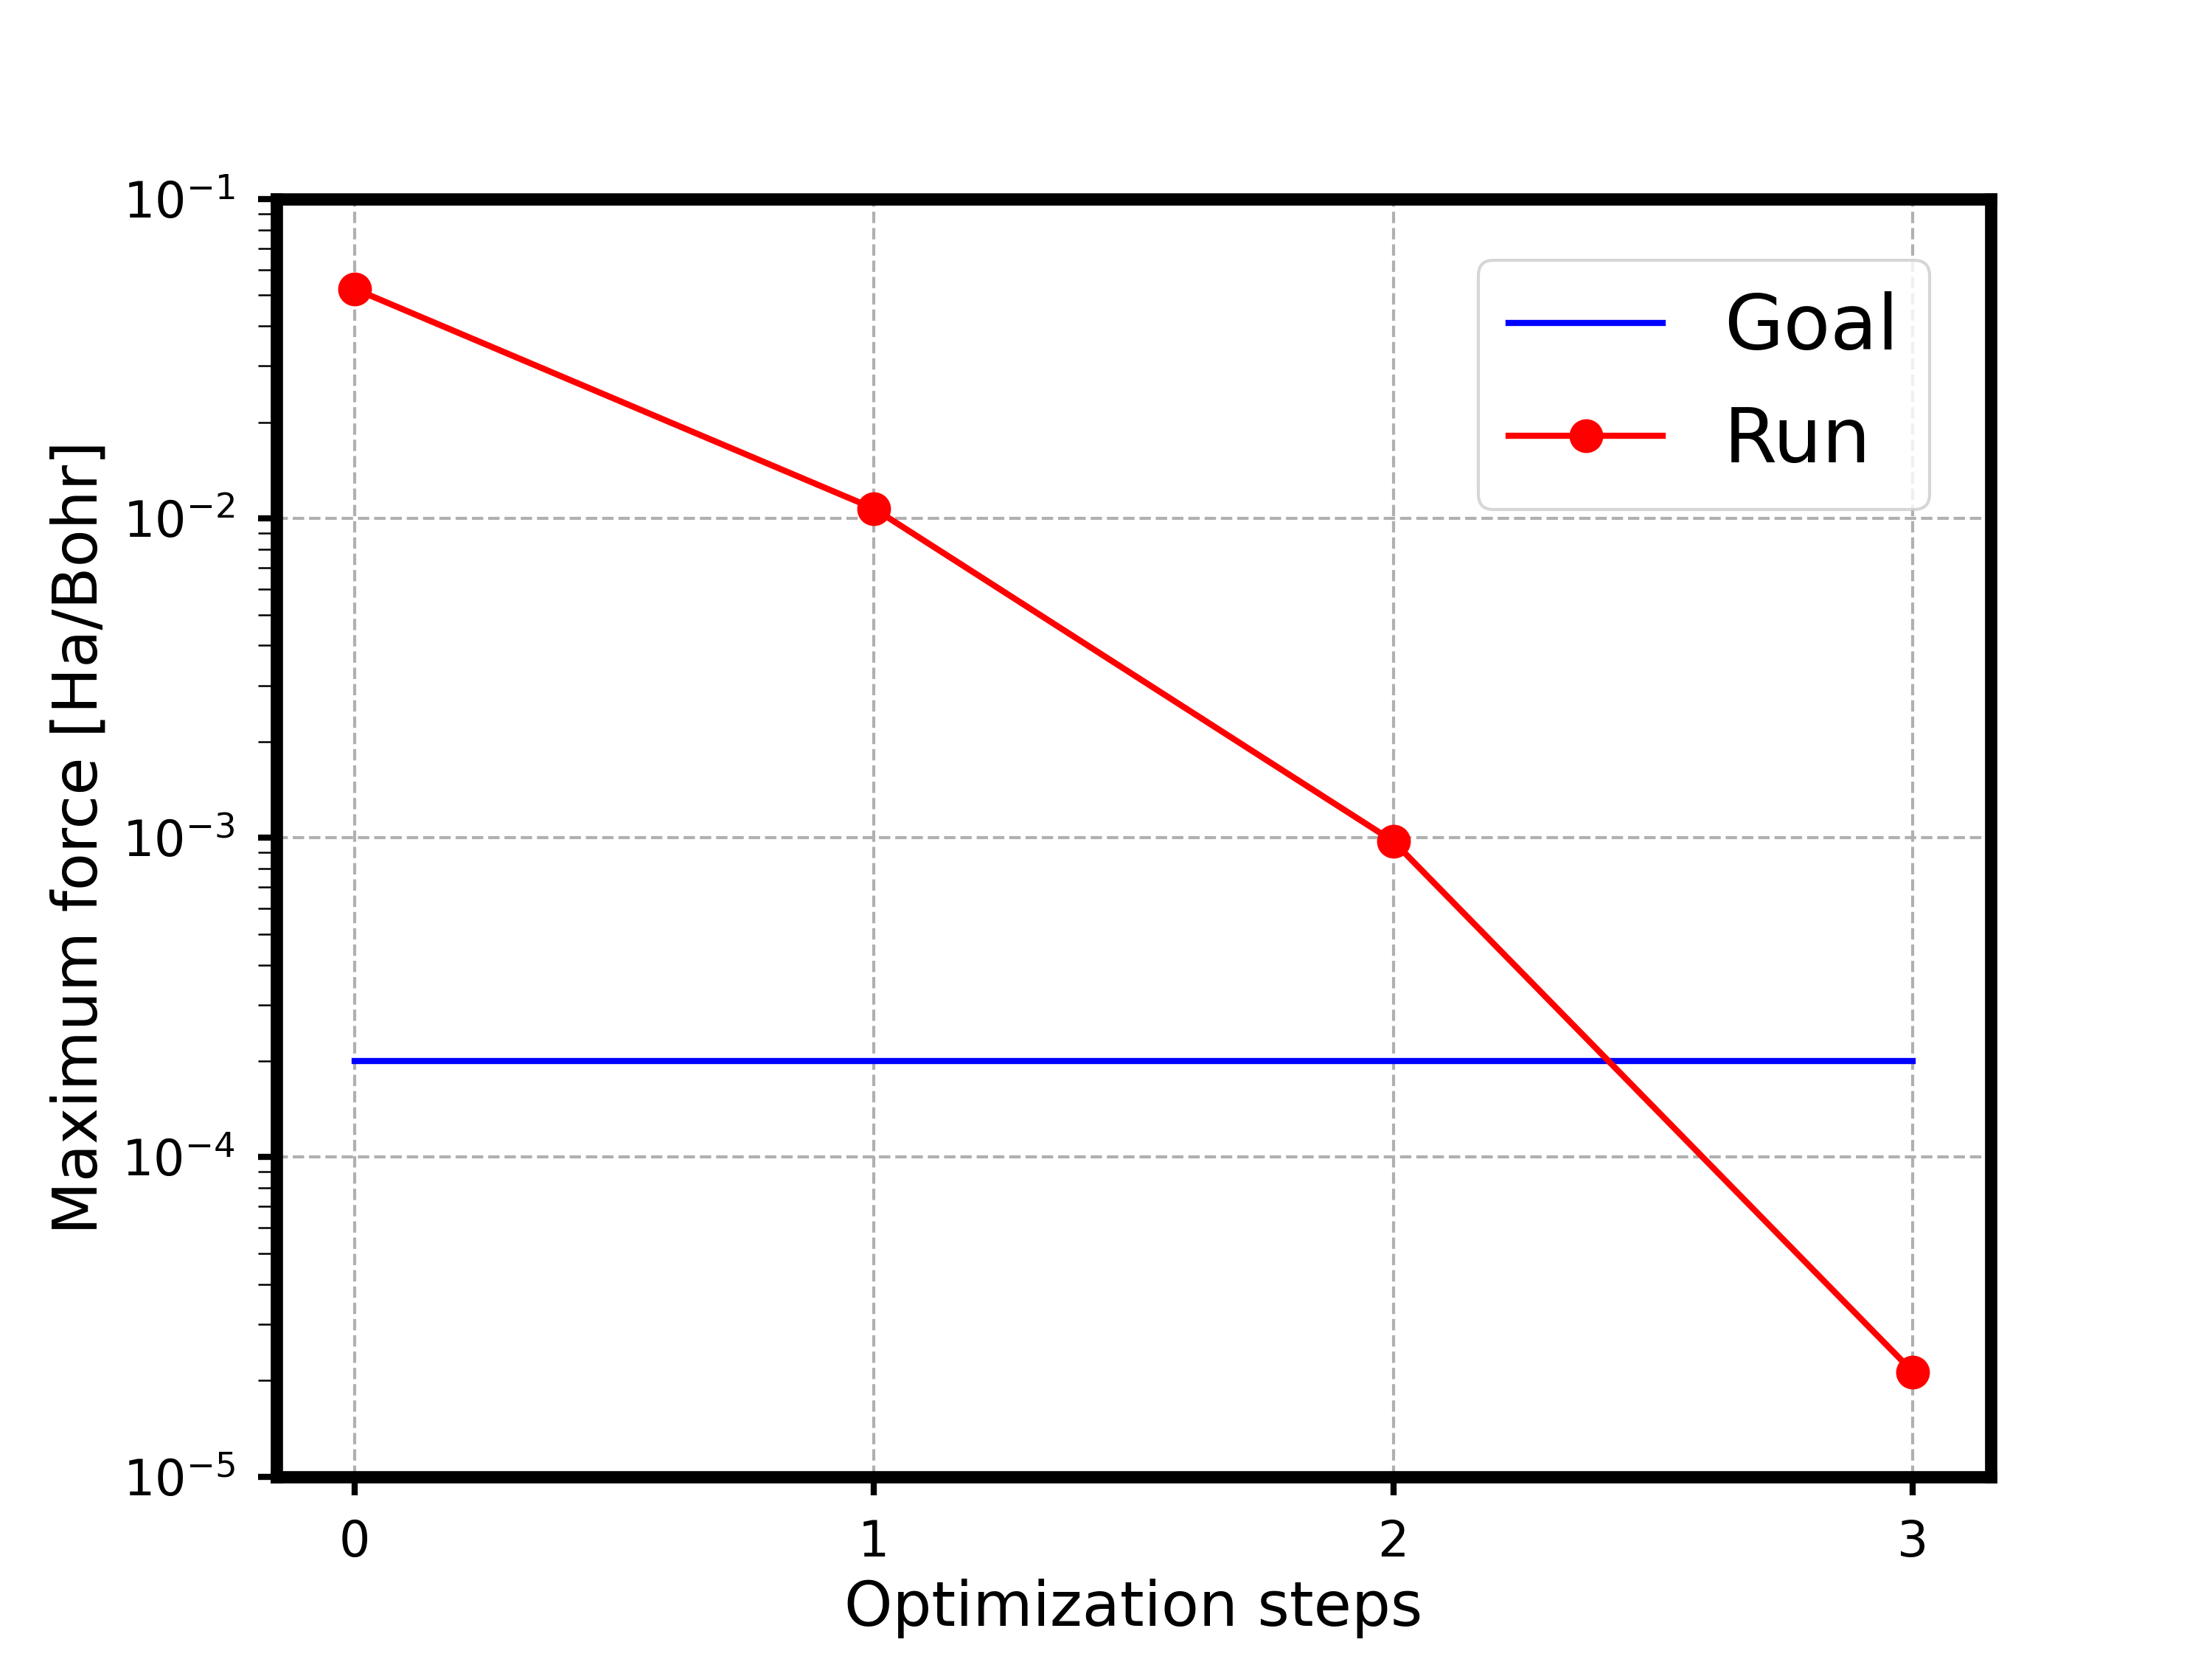
</figure>

The <span style="color:red;font-weight:bold">red</span> points show the calculated value at each optimization step, whereas the <span style="color:mediumblue;font-weight:bold">blue</span> line indicates the target value of the maximum amplitude of the force for stopping the relaxation.

<b>v) <code>plot.optimized_geometry.py</code></b>

Python visualization tool for showing the optimized geometry compared to the reference (unrelaxed) geometry for the relative atomic coordinates of two atoms in the unit cell as a function of Lagrangian strain.</span> <span style="color:green;font-weight:bold">It is useful for deformations which allow for internal relaxation of atomic positions, e.g., for the deformation with the code</span> <span style="color:red;font-weight:bold">7</span>. It is executed as follows.

<code>python3 -m excitingscripts.plot.optimized_geometry --a1 ATOM1 --a2 ATOM2 --y_min YMIN --y_max YMAX</code>

Up to four <span style="color:red;font-weight:bold">optional</span> entries can be specified <span style="color:red;font-weight:bold">on the calling line</span>. The first two entries are numeric labels of the atoms referring to the listing of the atoms in the input file input.xml. For instance, setting <b>ATOM1 = 2</b> and <b>ATOM2 = 6</b> (for a cell containing at least 6 atoms!) means that one considers the second and the sixth atoms, as listed in <b>input.xml</b> (including atoms of all species). If <b>ATOM1</b> and <b>ATOM2</b> are not specified, their <span style="color:red;font-weight:bold">default values</span> are <span style="color:red;font-weight:bold">1</span> and <span style="color:red;font-weight:bold">2</span>, respectively. In case <b>ATOM1</b> and <b>ATOM2</b> are explicitly given, you can set the minimum (<span style="color:red;font-weight:bold">YMIN</span>) and the maximum (<span style="color:red;font-weight:bold">YMAX</span>) value on the vertical axis, respectively. An example of the output of the script for the deformation code <span style="color:red;font-weight:bold">7</span> is the following.



<figure>
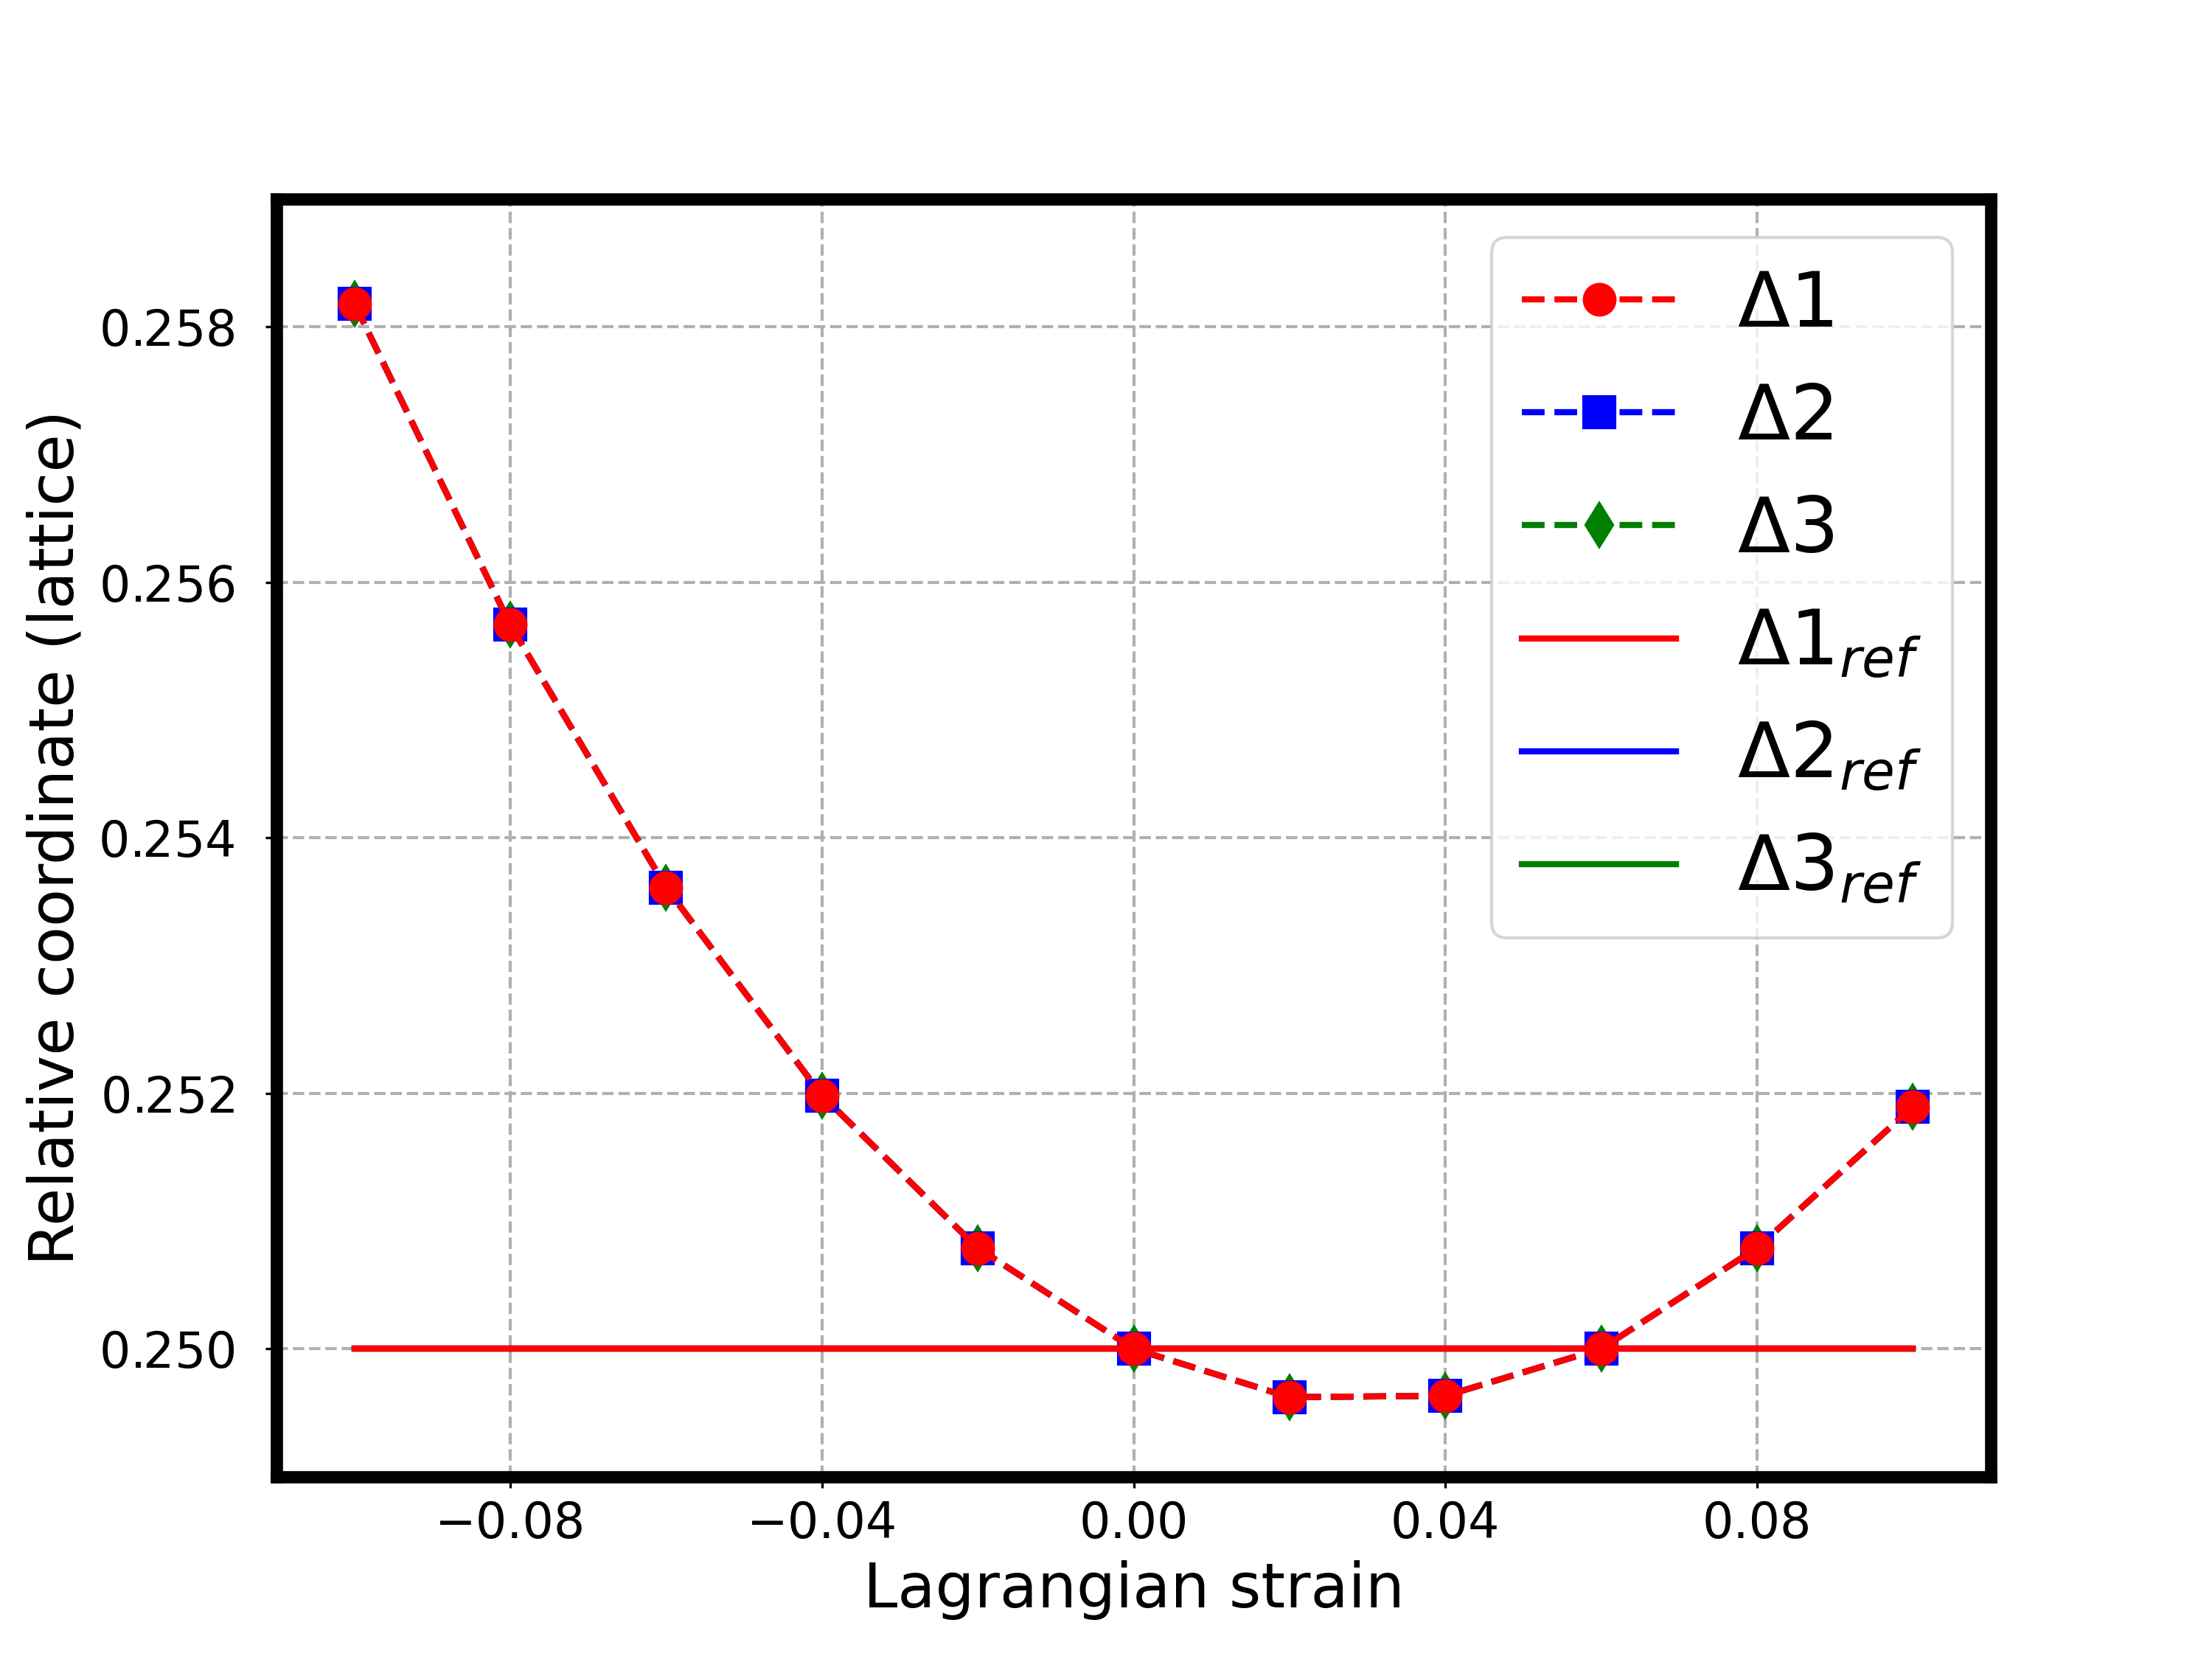
</figure>

Here, <span style="color:mediumblue;font-weight:bold">(Δ1, Δ2, Δ3)</span> and <span style="color:mediumblue;font-weight:bold">(Δ1<sub>ref</sub>, Δ2<sub>ref</sub>, Δ3<sub>ref</sub>)</span> represent the position difference vector, <span style="color:mediumblue;font-weight:bold">r<sub>ATOM2</sub> - r<sub>ATOM1</sub></span>, expressed in lattice coordinates, for the optimized geometry and the unrelaxed (reference) case, respectively.

<a id='6'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">6. Post-processing: How to derive elastic constant</span>

Second derivatives calculated at zero strain of energy-vs-strain curves are combinations of the elastic constants C<sub>ij</sub> where the indexes i,j=1,2,…,6 are given in the Voigt notation. In the example that we are considering here, carbon in the cubic diamond structure, only 3 different elastic constants are non vanishing

* C<sub>11</sub>
* C<sub>12</sub>
* C<sub>44</sub>

In order to extract these three elastic constants, three different deformation types must be used. For cubic systems the best choice is represented by the following deformation types

* Volume strain (in our script corresponding to the label <span style="color:red;font-weight:bold">0</span>)
* Uniaxial strain in the 100 direction (label <span style="color:red;font-weight:bold">1</span>)
* Shear strain along the 111 direction (label <span style="color:red;font-weight:bold">7</span>)

Which in turns correspond to the following combination of elastic constants:

* <span style="color:red;font-weight:bold">label 0:</span> 3 C<sub>11</sub>+ 6 C<sub>12</sub> = 9 B<sub>0</sub>
* <span style="color:red;font-weight:bold">label 1:</span> C<sub>11</sub>
* <span style="color:red;font-weight:bold">label 7:</span> 3 C<sub>44</sub>

where B<sub>0</sub> the bulk modulus.

<span style="color:green;font-weight:bold">Experimental reference values for diamond:</span>

* <span style="color:green;">C<sub>11</sub> = 1076 GPa</span>
* <span style="color:green;">C<sub>12</sub> = 125 GPa</span>
* <span style="color:green;">C<sub>44</sub> = 577 GPa</span>
* <span style="color:green;">B<sub>0</sub> = 452 GPa</span>

<hr style="border:2px solid #DDD"> </hr>